In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA = '/Users/sea/dev/alpha-wolves/datasets/round3/'
DAYS = [0, 1, 2]
STRIKES = [4500, 5000, 5100, 5200, 5300]
TICKS_PER_DAY = 10_000
TOTAL_DAYS = 5        # expiry from day 0
TOTAL_TICKS = TICKS_PER_DAY * TOTAL_DAYS  # 50,000

dfs = []
for d in DAYS:
    df = pd.read_csv(f'{DATA}prices_round_3_day_{d}.csv', sep=';')
    df['day'] = d
    dfs.append(df)
prices = pd.concat(dfs, ignore_index=True)

vfe = prices[prices['product'] == 'VELVETFRUIT_EXTRACT'].copy()
vfe['global_tick'] = vfe['day'] * TICKS_PER_DAY + (vfe['timestamp'] // 100).astype(int)
vfe = vfe.sort_values('global_tick').reset_index(drop=True)
vfe['log_ret'] = np.log(vfe['mid_price'] / vfe['mid_price'].shift(1))
vfe['sigma']   = vfe['log_ret'].rolling(200).std().bfill()
print(vfe[['global_tick','mid_price','sigma']].describe())

        global_tick     mid_price         sigma
count  30000.000000  30000.000000  30000.000000
mean   14999.500000   5250.098100      0.000215
std     8660.398374     15.630415      0.000013
min        0.000000   5198.000000      0.000179
25%     7499.750000   5238.500000      0.000207
50%    14999.500000   5249.500000      0.000214
75%    22499.250000   5262.500000      0.000223
max    29999.000000   5300.000000      0.000260


In [29]:
def binomial_european(S, K, sigma, T_ticks, N=50):
    """CRR binomial tree, European call, r=0."""
    if T_ticks <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    dt = T_ticks / N
    u  = np.exp(sigma * np.sqrt(dt))
    d  = 1.0 / u
    p  = max(0.0, min(1.0, (1 - d) / (u - d)))  # r=0 → p=(1-d)/(u-d)
    j  = np.arange(N + 1)
    ST = S * (u ** (N - j)) * (d ** j)
    V  = np.maximum(ST - K, 0.0)
    for _ in range(N):
        V = p * V[:-1] + (1 - p) * V[1:]
    return float(V[0])

# sanity check
S, sigma = 5250, 0.0002
for K in STRIKES:
    T = TOTAL_TICKS
    print(f'K={K}  model={binomial_european(S, K, sigma, T):.2f}')

K=4500  model=750.01
K=5000  model=265.92
K=5100  model=186.24
K=5200  model=120.55
K=5300  model=71.44


In [30]:
# Price each option at every tick, compare to market
results = []
for strike in STRIKES:
    prod = f'VEV_{strike}'
    opt = prices[prices['product'] == prod][['day','timestamp','mid_price']].copy()
    opt['global_tick'] = opt['day'] * TICKS_PER_DAY + (opt['timestamp'] // 100).astype(int)
    opt = opt.sort_values('global_tick').reset_index(drop=True)
    opt = opt.merge(
        vfe[['global_tick','mid_price','sigma']].rename(columns={'mid_price':'S'}),
        on='global_tick', how='left')
    opt['sigma']   = opt['sigma'].ffill().bfill()
    opt['T_ticks'] = TOTAL_TICKS - opt['global_tick']
    opt['model']   = opt.apply(
        lambda r: binomial_european(r['S'], strike, r['sigma'], max(r['T_ticks'], 1)), axis=1)
    opt['mkt']     = opt['mid_price']
    opt['misp']    = opt['mkt'] - opt['model']
    opt['strike']  = strike
    results.append(opt)
    print(f'VEV_{strike}: model={opt["model"].mean():.1f}  market={opt["mkt"].mean():.1f}  '
          f'bias={opt["misp"].mean():.1f}  std={opt["misp"].std():.1f}')

all_opts = pd.concat(results, ignore_index=True)

VEV_4500: model=750.1  market=750.1  bias=0.0  std=0.8
VEV_5000: model=261.8  market=255.0  bias=-6.8  std=4.4
VEV_5100: model=179.0  market=166.8  bias=-12.2  std=5.9
VEV_5200: model=111.1  market=95.5  bias=-15.6  std=7.9
VEV_5300: model=61.8  market=46.8  bias=-15.0  std=8.2


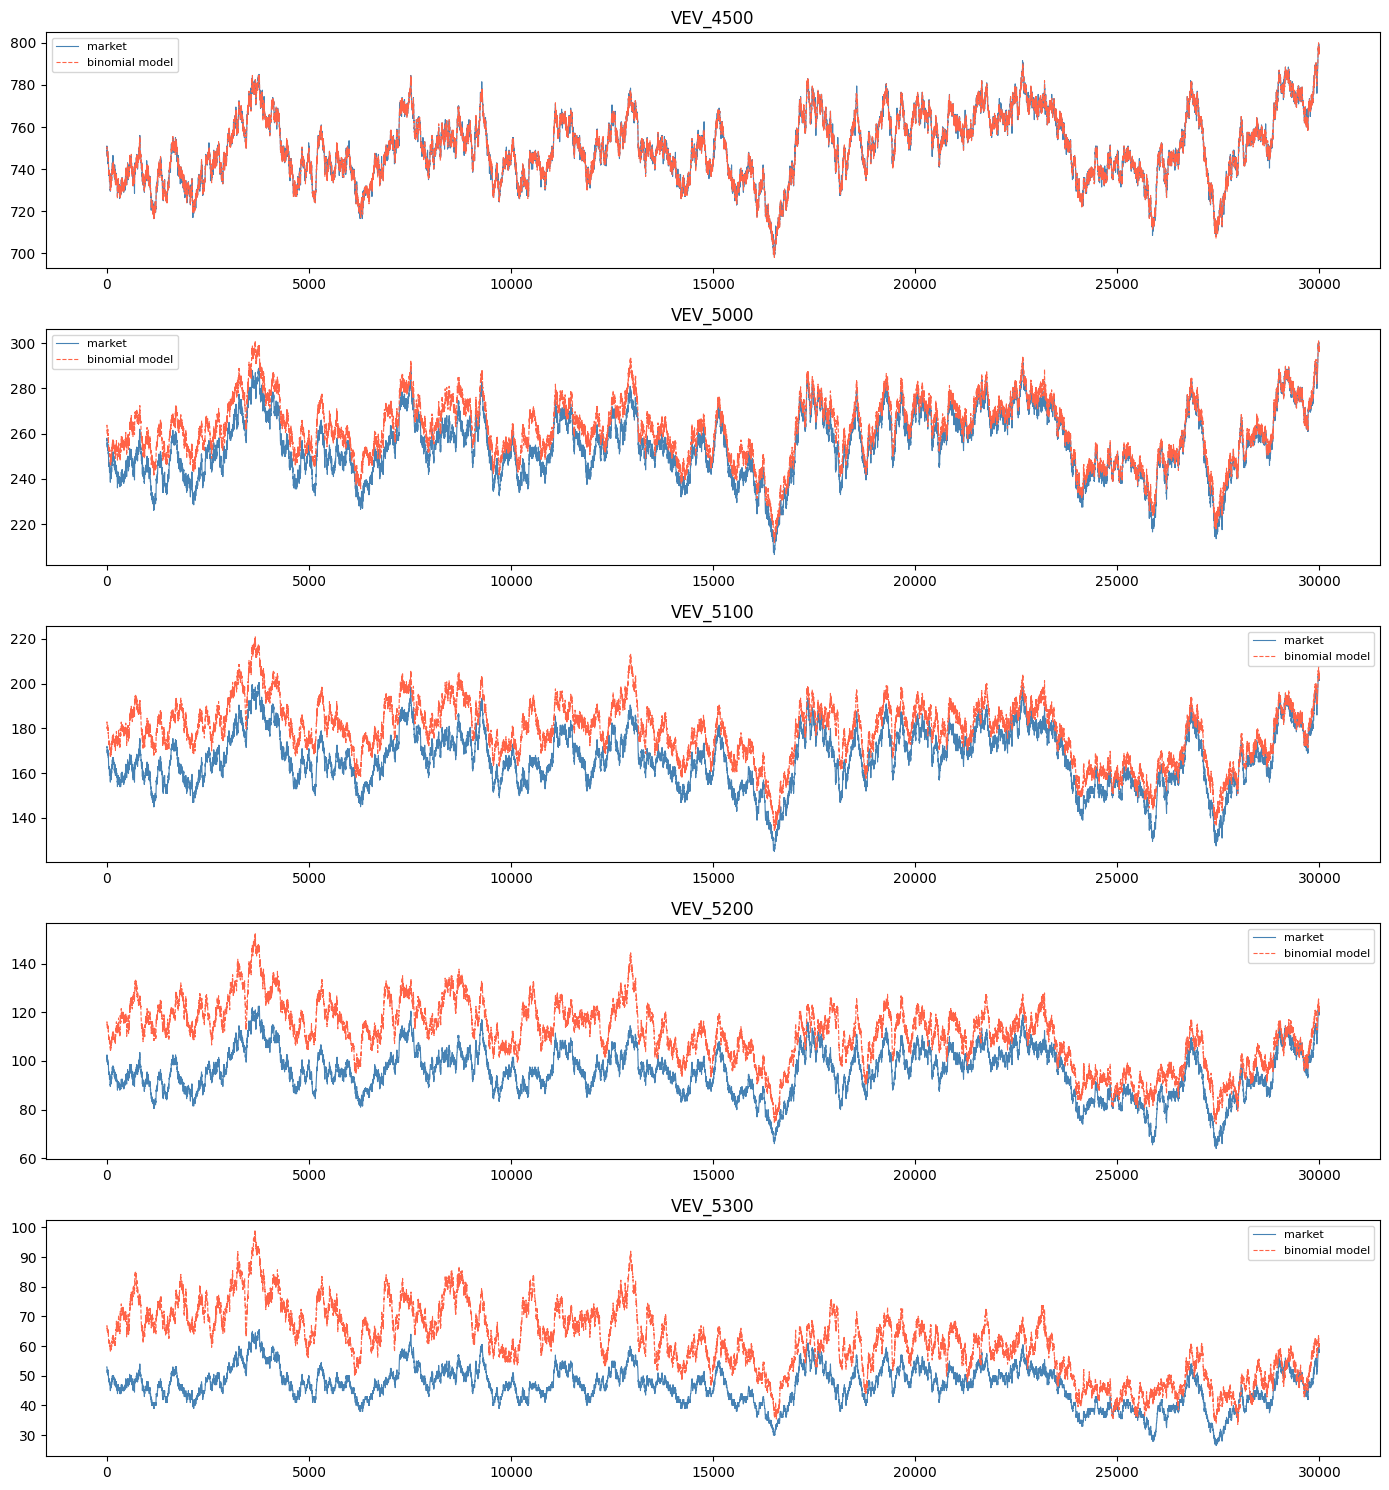

In [31]:
# Plot model vs market price for each strike
fig, axes = plt.subplots(len(STRIKES), 1, figsize=(14, 3*len(STRIKES)))
for ax, strike in zip(axes, STRIKES):
    d = all_opts[all_opts['strike'] == strike]
    ax.plot(d['global_tick'], d['mkt'],   lw=0.8, color='steelblue', label='market')
    ax.plot(d['global_tick'], d['model'], lw=0.8, color='tomato', ls='--', label='binomial model')
    ax.set_title(f'VEV_{strike}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

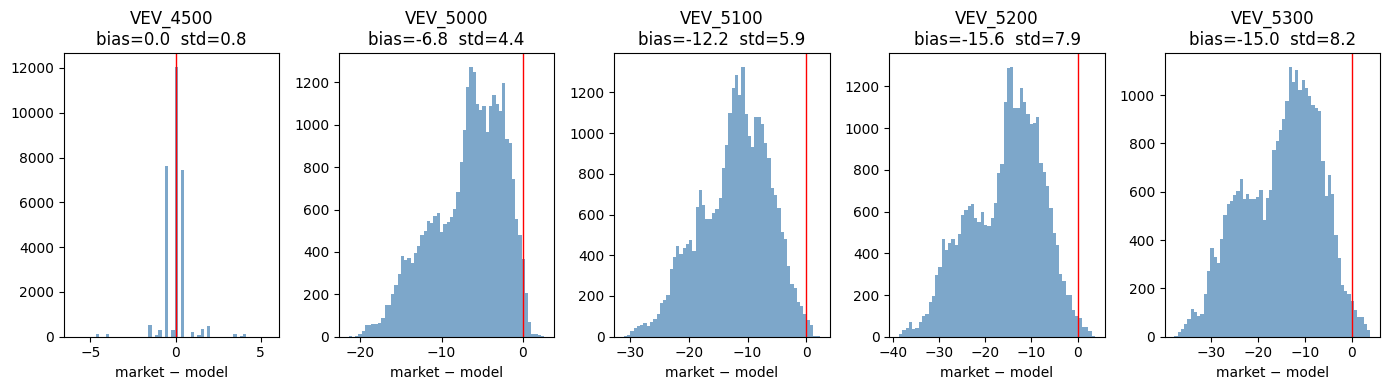

In [32]:
# Mispricing distributions (market - model)
fig, axes = plt.subplots(1, len(STRIKES), figsize=(14, 4))
for ax, strike in zip(axes, STRIKES):
    d = all_opts[all_opts['strike'] == strike]['misp'].dropna()
    ax.hist(d, bins=60, color='steelblue', alpha=0.7)
    ax.axvline(0, color='red', lw=1)
    ax.set_title(f'VEV_{strike}\nbias={d.mean():.1f}  std={d.std():.1f}')
    ax.set_xlabel('market − model')
plt.tight_layout()
plt.show()

VEV_4500: BS bias = 0.00
VEV_5000: BS bias = -6.76
VEV_5100: BS bias = -12.16
VEV_5200: BS bias = -15.58
VEV_5300: BS bias = -14.99


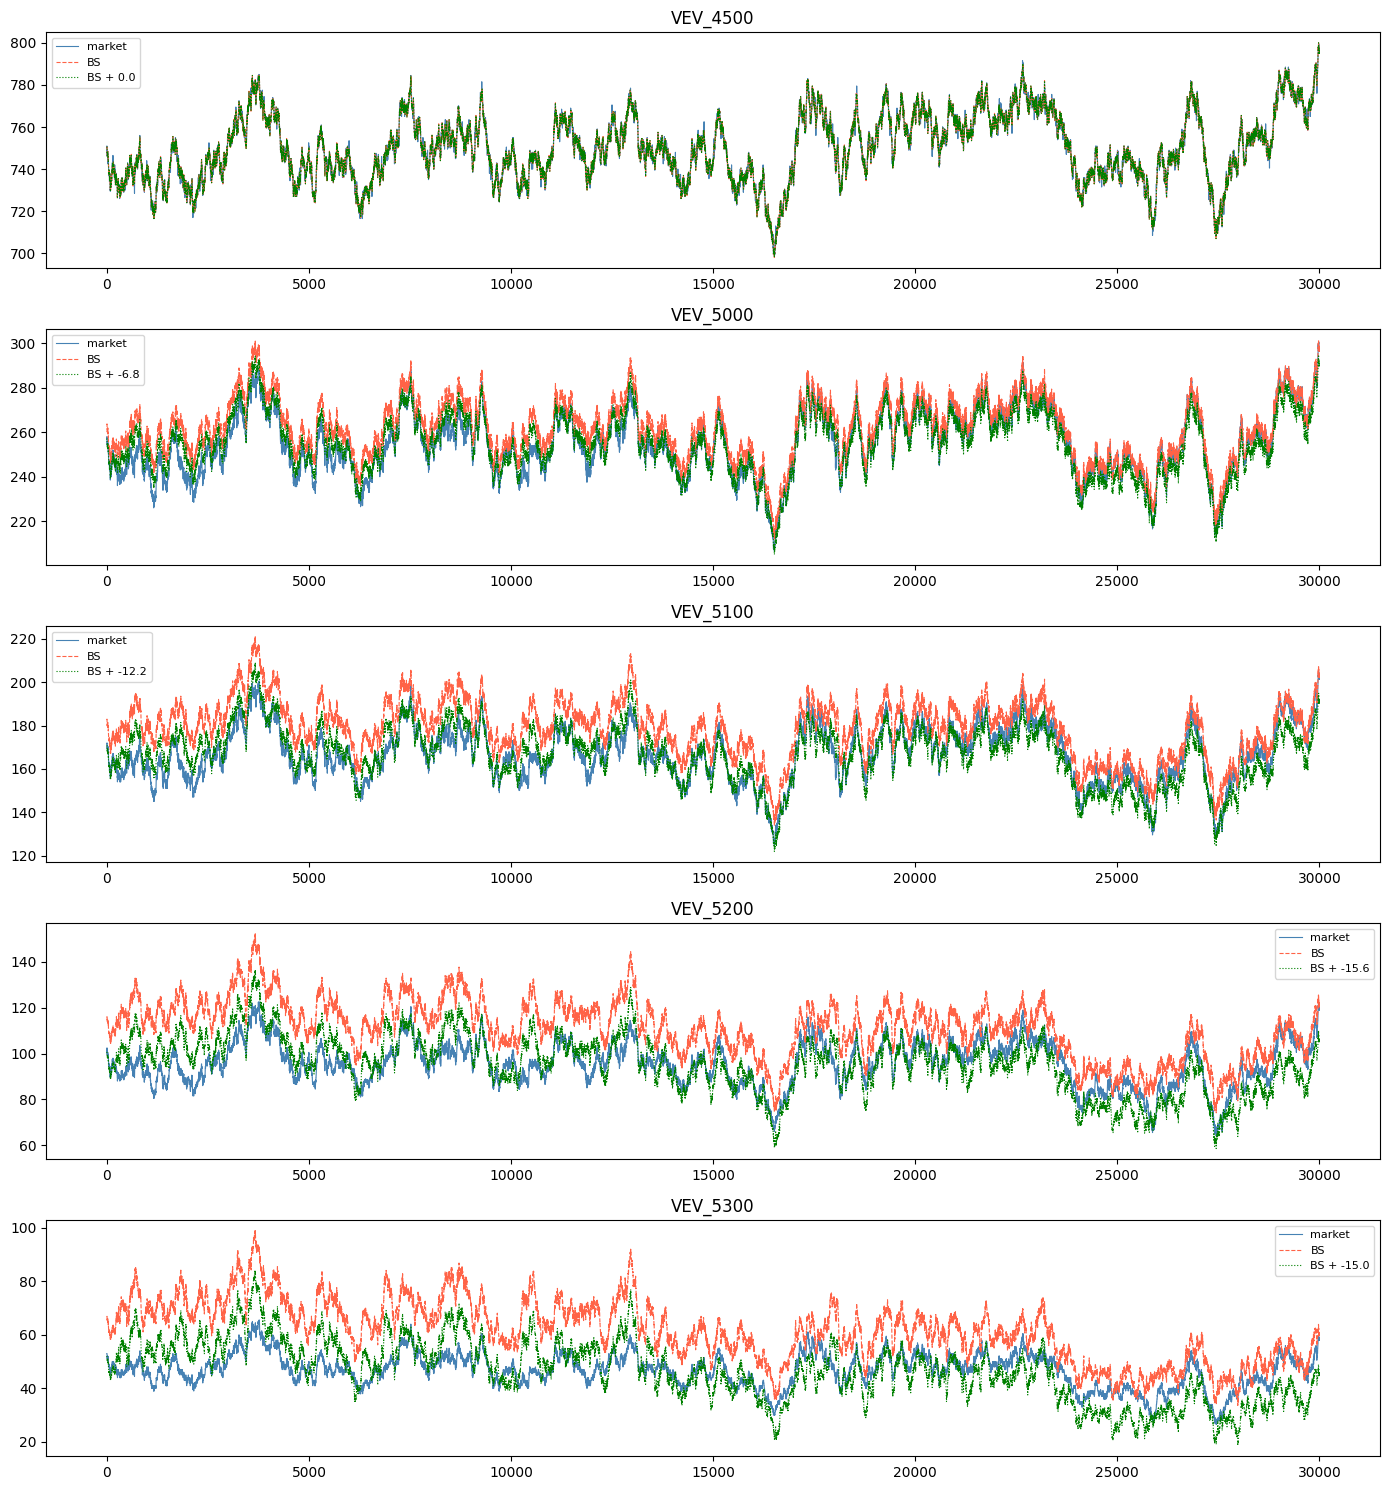

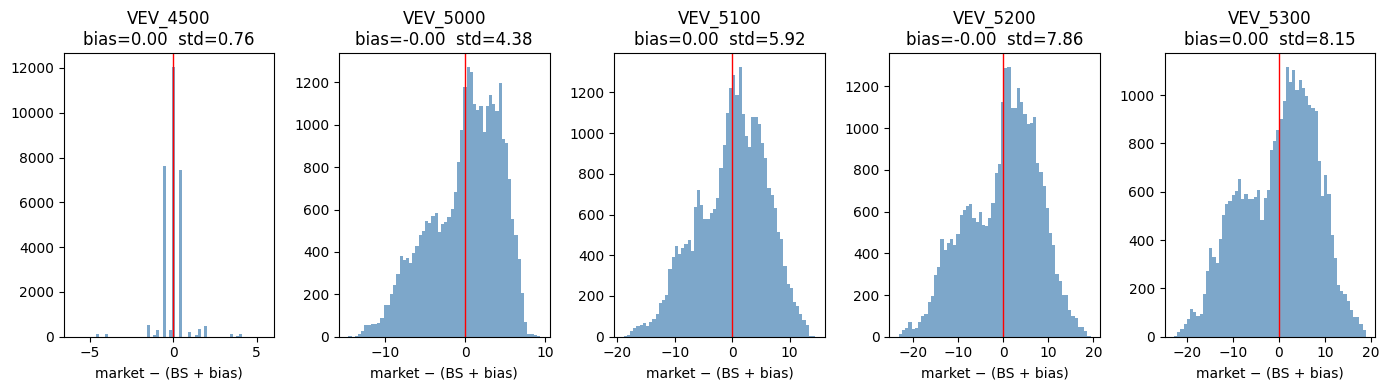

In [33]:
# Black-Scholes calibrated: add per-strike mean bias to model price
bias = {}
for strike in STRIKES:
    d = all_opts[all_opts['strike'] == strike]
    bias[strike] = d['misp'].mean()
    print(f'VEV_{strike}: BS bias = {bias[strike]:.2f}')

# Replot: market vs BS vs BS+bias
fig, axes = plt.subplots(len(STRIKES), 1, figsize=(14, 3*len(STRIKES)))
for ax, strike in zip(axes, STRIKES):
    d = all_opts[all_opts['strike'] == strike]
    ax.plot(d['global_tick'], d['mkt'],                         lw=0.8, color='steelblue', label='market')
    ax.plot(d['global_tick'], d['model'],                       lw=0.8, color='tomato',    ls='--', label='BS')
    ax.plot(d['global_tick'], d['model'] + bias[strike],        lw=0.8, color='green',     ls=':',  label=f'BS + {bias[strike]:.1f}')
    ax.set_title(f'VEV_{strike}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Residual mispricing after correction
fig, axes = plt.subplots(1, len(STRIKES), figsize=(14, 4))
for ax, strike in zip(axes, STRIKES):
    d = all_opts[all_opts['strike'] == strike]
    resid = d['mkt'] - (d['model'] + bias[strike])
    ax.hist(resid.dropna(), bins=60, color='steelblue', alpha=0.7)
    ax.axvline(0, color='red', lw=1)
    ax.set_title(f'VEV_{strike}\nbias={resid.mean():.2f}  std={resid.std():.2f}')
    ax.set_xlabel('market − (BS + bias)')
plt.tight_layout()
plt.show()

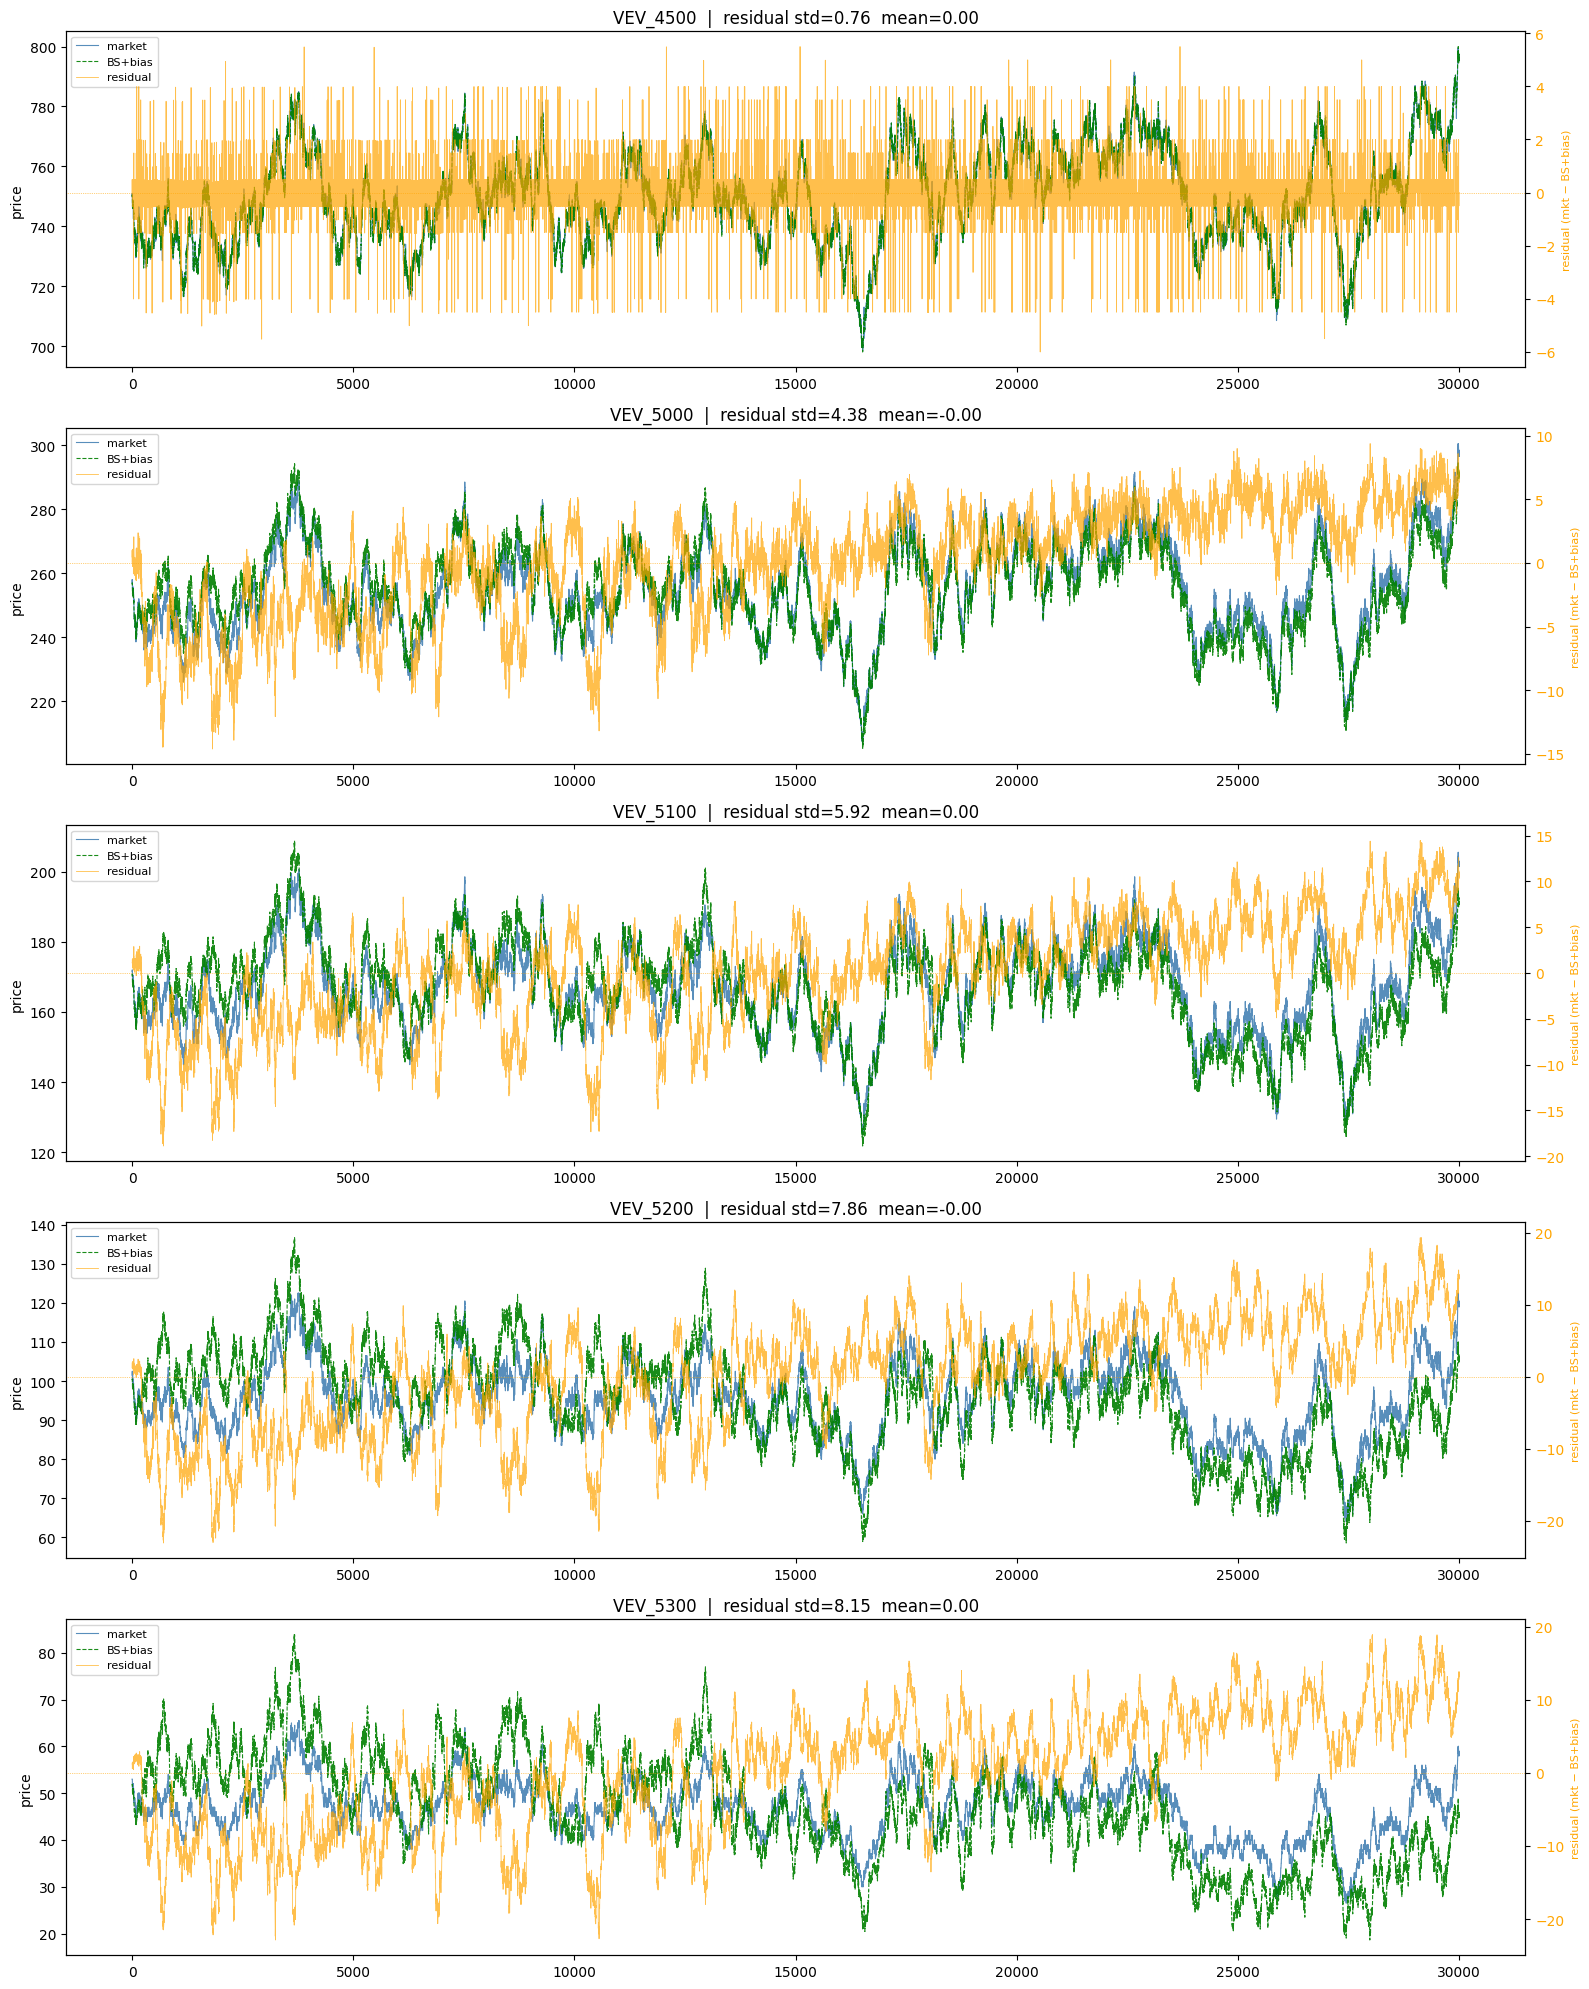

In [34]:
# Plot residuals, BS+bias, and market price on same axis per strike
fig, axes = plt.subplots(len(STRIKES), 1, figsize=(16, 4*len(STRIKES)))
for ax, strike in zip(axes, STRIKES):
    d = all_opts[all_opts['strike'] == strike].copy()
    calibrated = d['model'] + bias[strike]
    resid = d['mkt'] - calibrated

    ax.plot(d['global_tick'], d['mkt'],       lw=0.8, color='steelblue', label='market',     alpha=0.9)
    ax.plot(d['global_tick'], calibrated,     lw=0.8, color='green',     label='BS+bias',    alpha=0.9, ls='--')

    ax2 = ax.twinx()
    ax2.plot(d['global_tick'], resid,         lw=0.6, color='orange',    label='residual',   alpha=0.7)
    ax2.axhline(0, color='orange', lw=0.5, ls=':')
    ax2.set_ylabel('residual (mkt − BS+bias)', color='orange', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='orange')

    ax.set_title(f'VEV_{strike}  |  residual std={resid.std():.2f}  mean={resid.mean():.2f}')
    ax.set_ylabel('price')
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()


In [35]:
from scipy.optimize import brentq

def implied_vol(market_price, S, K, T, tol=1e-6):
    """Back-solve BS call for implied vol. Returns NaN if no solution."""
    if T <= 0 or S <= 0:
        return np.nan
    intrinsic = max(S - K, 0.0)
    if market_price <= intrinsic + tol:
        return np.nan
    try:
        return brentq(lambda v: bs_call(S, K, v, T) - market_price, 1e-6, 10.0, xtol=tol)
    except (ValueError, RuntimeError):
        return np.nan

# Compute implied vol per strike at every tick
iv_results = []
for strike in STRIKES:
    prod = f'VEV_{strike}'
    opt = prices[prices['product'] == prod][['day','timestamp','mid_price']].copy()
    opt['global_tick'] = opt['day'] * TICKS_PER_DAY + (opt['timestamp'] // 100).astype(int)
    opt = opt.sort_values('global_tick').reset_index(drop=True)
    opt = opt.merge(
        vfe[['global_tick','mid_price']].rename(columns={'mid_price':'S'}),
        on='global_tick', how='left')
    opt['T_ticks'] = TOTAL_TICKS - opt['global_tick']
    opt['iv'] = opt.apply(
        lambda r: implied_vol(r['mid_price'], r['S'], strike, max(r['T_ticks'], 1)),
        axis=1)
    opt['strike'] = strike
    iv_results.append(opt)
    print(f'VEV_{strike}: iv mean={opt["iv"].mean():.5f}  std={opt["iv"].std():.5f}  '
          f'min={opt["iv"].min():.5f}  max={opt["iv"].max():.5f}')

all_iv = pd.concat(iv_results, ignore_index=True)


VEV_4500: iv mean=0.00034  std=0.00005  min=0.00026  max=0.00057
VEV_5000: iv mean=0.00017  std=0.00001  min=0.00013  max=0.00024
VEV_5100: iv mean=0.00017  std=0.00001  min=0.00015  max=0.00021
VEV_5200: iv mean=0.00018  std=0.00001  min=0.00015  max=0.00021
VEV_5300: iv mean=0.00018  std=0.00001  min=0.00016  max=0.00021


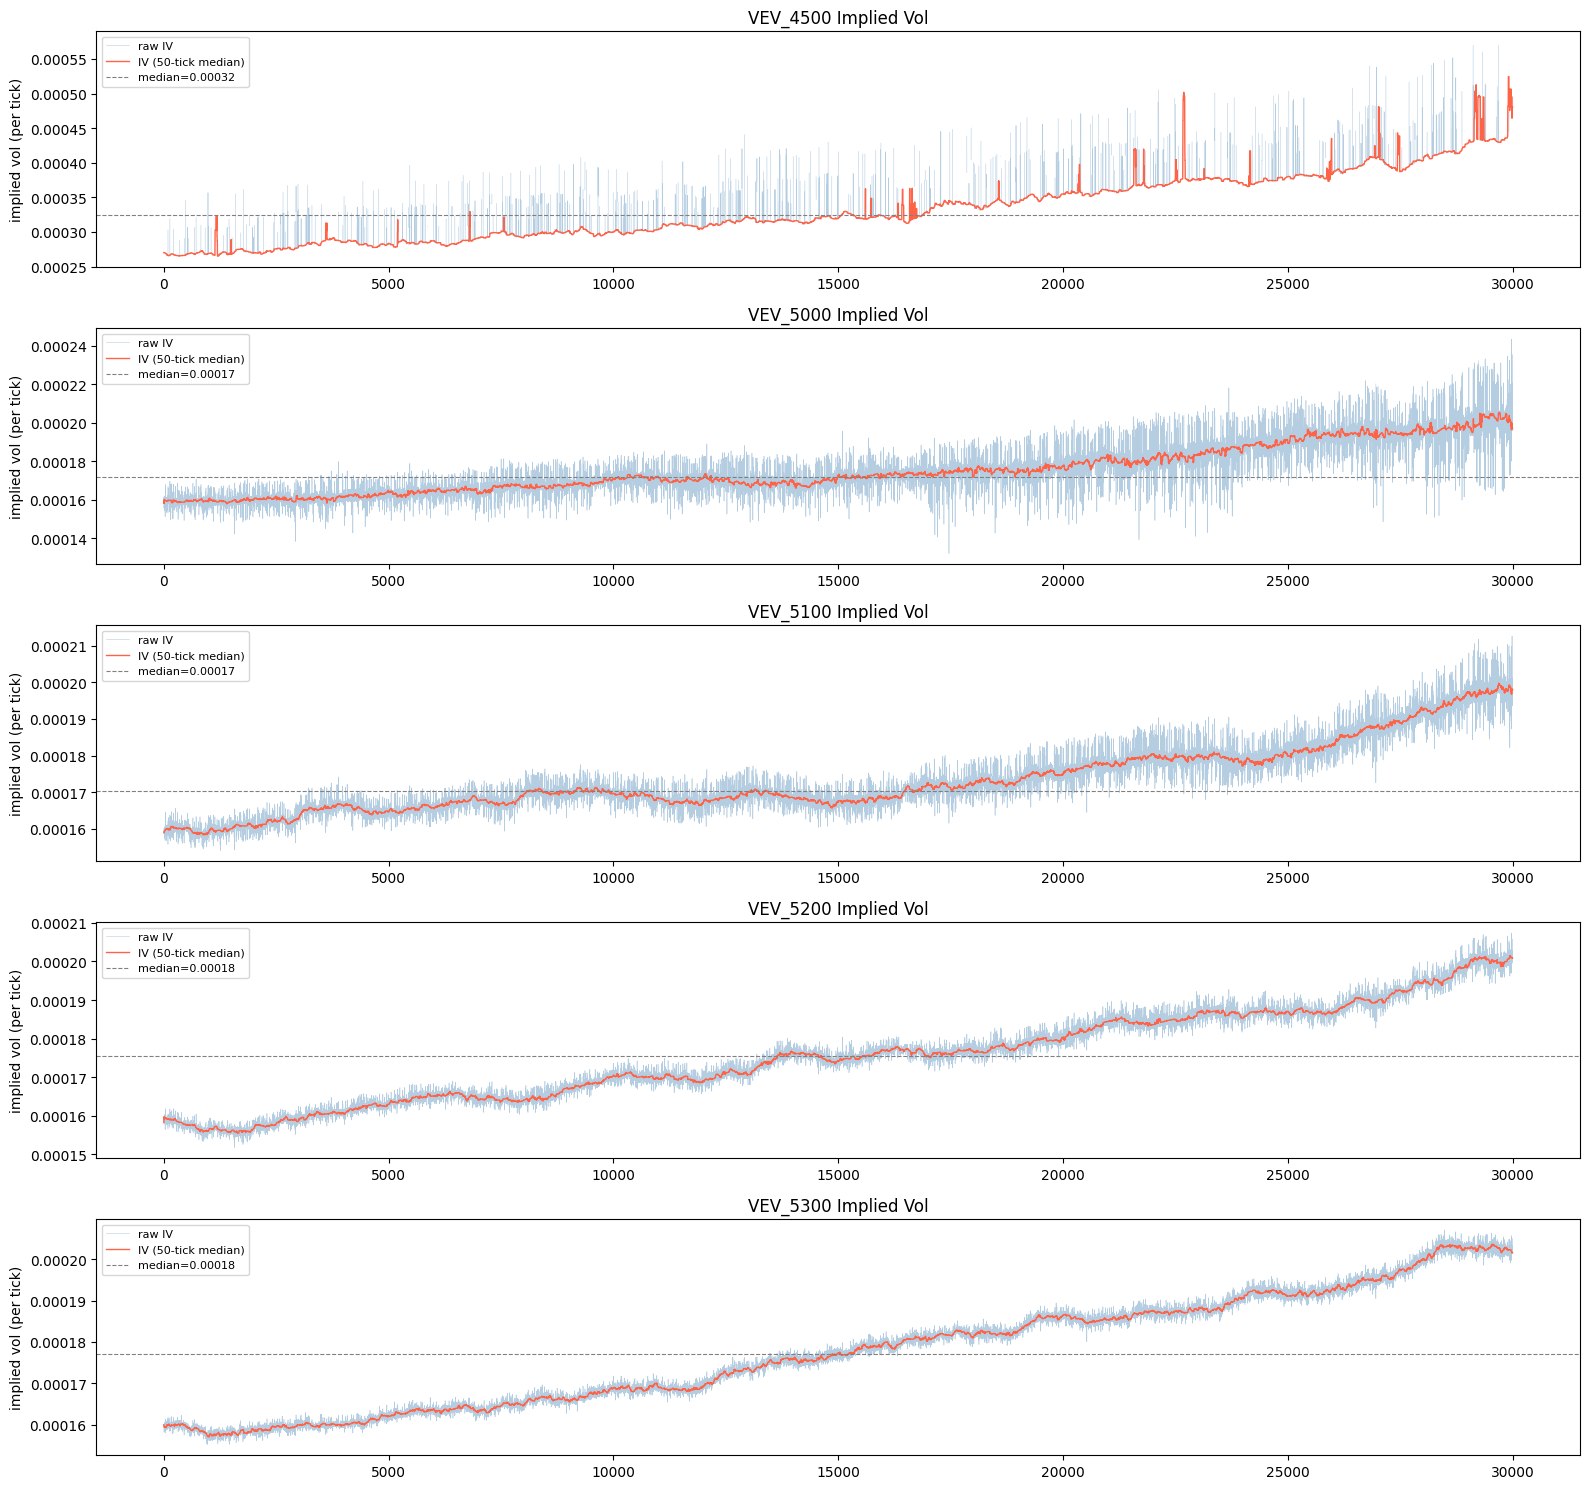

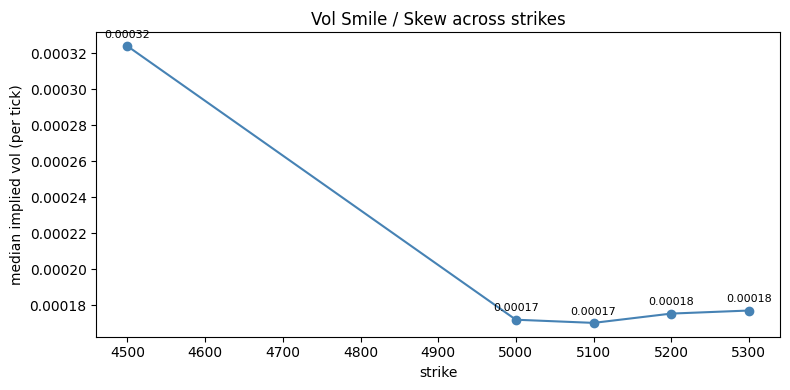

In [36]:
# Plot implied vol surface over time per strike
fig, axes = plt.subplots(len(STRIKES), 1, figsize=(16, 3*len(STRIKES)))
for ax, strike in zip(axes, STRIKES):
    d = all_iv[all_iv['strike'] == strike]
    iv_clean = d['iv'].rolling(50, min_periods=1).median()  # smooth out noise
    ax.plot(d['global_tick'], d['iv'],     lw=0.4, color='steelblue', alpha=0.4, label='raw IV')
    ax.plot(d['global_tick'], iv_clean,    lw=1.0, color='tomato',    label='IV (50-tick median)')
    ax.axhline(d['iv'].median(), color='gray', lw=0.8, ls='--', label=f'median={d["iv"].median():.5f}')
    ax.set_title(f'VEV_{strike} Implied Vol')
    ax.set_ylabel('implied vol (per tick)')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Vol smile: average IV per strike
fig, ax = plt.subplots(figsize=(8, 4))
median_ivs = [(s, all_iv[all_iv['strike']==s]['iv'].median()) for s in STRIKES]
strikes_plot, ivs_plot = zip(*median_ivs)
ax.plot(strikes_plot, ivs_plot, 'o-', color='steelblue')
for s, iv in median_ivs:
    ax.annotate(f'{iv:.5f}', (s, iv), textcoords='offset points', xytext=(0,6), ha='center', fontsize=8)
ax.set_xlabel('strike')
ax.set_ylabel('median implied vol (per tick)')
ax.set_title('Vol Smile / Skew across strikes')
plt.tight_layout()
plt.show()


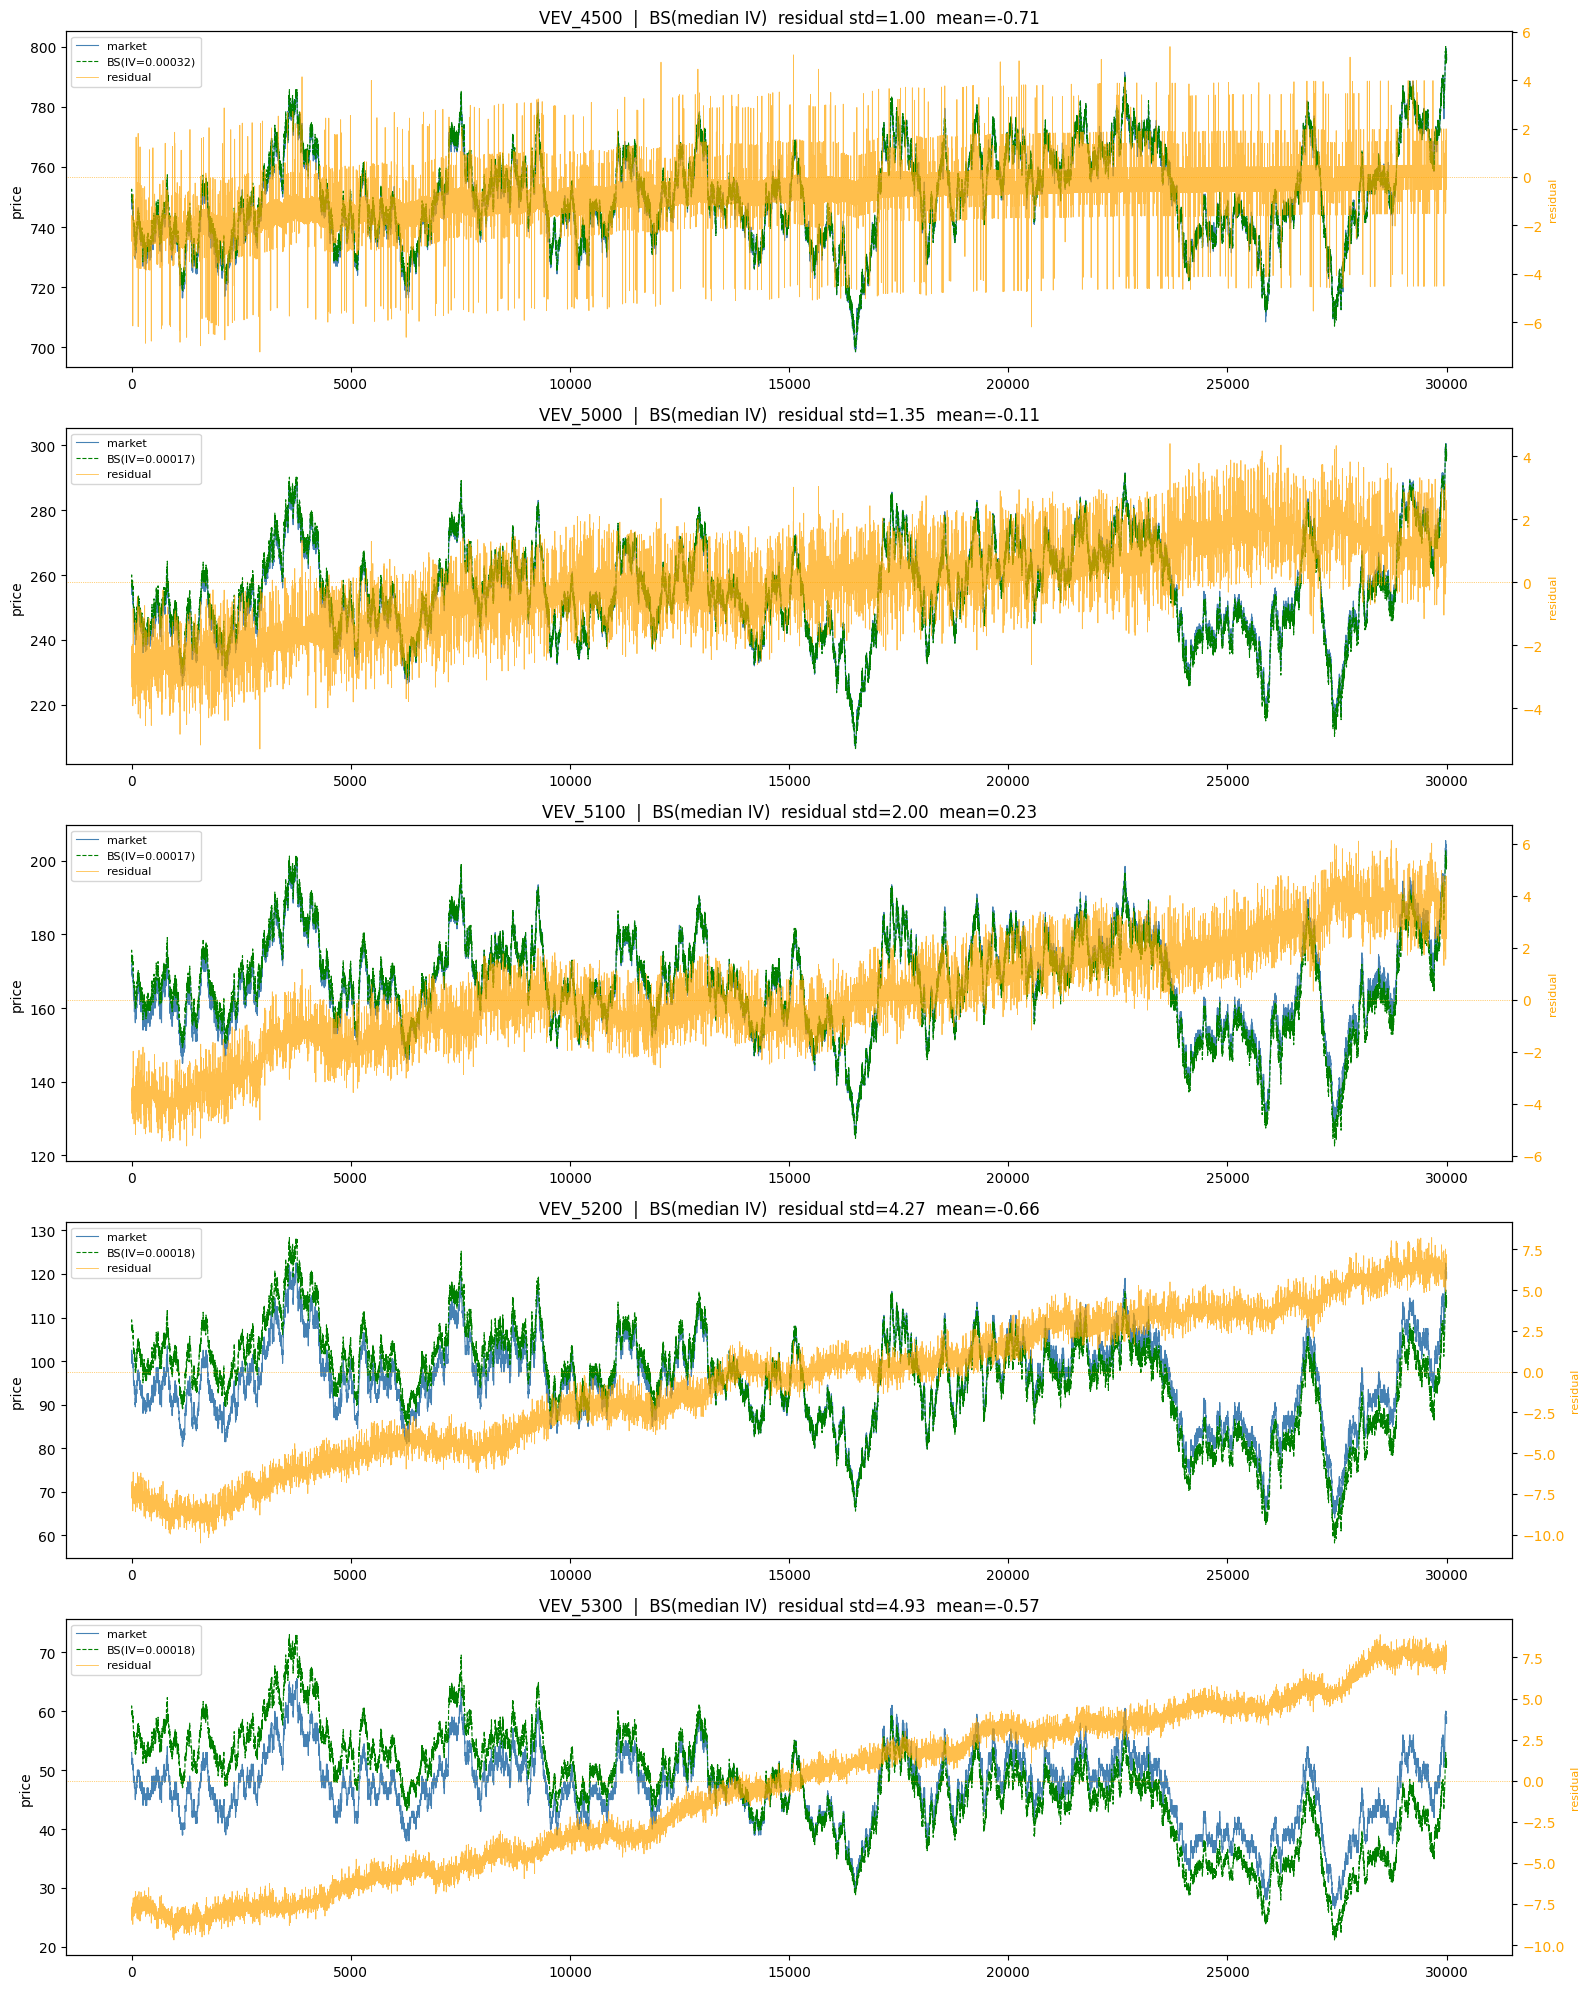

In [37]:
# Re-price using per-strike median IV and compute residuals
fig, axes = plt.subplots(len(STRIKES), 1, figsize=(16, 4*len(STRIKES)))
for ax, strike in zip(axes, STRIKES):
    d = all_iv[all_iv['strike'] == strike].copy()
    iv_med = d['iv'].median()
    d['model_iv'] = d.apply(
        lambda r: bs_call(r['S'], strike, iv_med, max(r['T_ticks'], 1)), axis=1)
    resid = d['mid_price'] - d['model_iv']

    ax.plot(d['global_tick'], d['mid_price'], lw=0.8, color='steelblue', label='market')
    ax.plot(d['global_tick'], d['model_iv'],  lw=0.8, color='green', ls='--', label=f'BS(IV={iv_med:.5f})')

    ax2 = ax.twinx()
    ax2.plot(d['global_tick'], resid, lw=0.6, color='orange', alpha=0.7, label='residual')
    ax2.axhline(0, color='orange', lw=0.5, ls=':')
    ax2.set_ylabel('residual', color='orange', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='orange')

    ax.set_title(f'VEV_{strike}  |  BS(median IV)  residual std={resid.std():.2f}  mean={resid.mean():.2f}')
    ax.set_ylabel('price')
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
from numpy.polynomial import polynomial as P

# Fit IV trend per strike, compute residual around trend
fig, axes = plt.subplots(len(STRIKES), 1, figsize=(16, 4*len(STRIKES)))
iv_trend_results = {}

for ax, strike in zip(axes, STRIKES):
    d = all_iv[all_iv['strike'] == strike].copy()
    d = d.dropna(subset=['iv']).reset_index(drop=True)

    t = d['global_tick'].values
    iv = d['iv'].values

    # fit linear trend to IV over time
    coeffs = np.polyfit(t, iv, deg=1)
    iv_trend = np.polyval(coeffs, t)
    iv_resid = iv - iv_trend

    d['iv_trend'] = iv_trend
    d['iv_resid'] = iv_resid

    # re-price with trended IV
    d['model_trend'] = d.apply(
        lambda r: bs_call(r['S'], strike, max(r['iv_trend'], 1e-6), max(r['T_ticks'], 1)), axis=1)
    price_resid = d['mid_price'] - d['model_trend']

    iv_trend_results[strike] = d

    ax.plot(t, iv,       lw=0.4, color='steelblue', alpha=0.5, label='raw IV')
    ax.plot(t, iv_trend, lw=1.2, color='tomato',    label=f'linear trend  slope={coeffs[0]:.2e}')
    ax2 = ax.twinx()
    ax2.plot(t, iv_resid, lw=0.6, color='orange', alpha=0.7, label='IV residual')
    ax2.axhline(0, color='orange', lw=0.5, ls=':')
    ax2.set_ylabel('IV − trend', color='orange', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='orange')

    ax.set_title(f'VEV_{strike}  |  IV trend  resid std={iv_resid.std():.6f}  '
                 f'price resid std={price_resid.std():.2f}')
    ax.set_ylabel('implied vol')
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
# Print coefficients for hardcoding into trader
print("IV linear trend coefficients (slope, intercept) per strike:")
for strike in STRIKES:
    d = all_iv[all_iv['strike'] == strike].dropna(subset=['iv'])
    t = d['global_tick'].values
    iv = d['iv'].values
    coeffs = np.polyfit(t, iv, deg=1)
    print(f"  {strike}: slope={coeffs[0]:.10e}  intercept={coeffs[1]:.8f}")
print()
print("Median IV per strike (fallback):")
for strike in STRIKES:
    d = all_iv[all_iv['strike'] == strike]
    print(f"  {strike}: {d['iv'].median():.8f}")


In [ ]:
# Plot price residual (market - BS(trended IV)) — this is the trading signal
fig, axes = plt.subplots(len(STRIKES), 1, figsize=(16, 4*len(STRIKES)))
for ax, strike in zip(axes, STRIKES):
    d = iv_trend_results[strike]
    resid = d['mid_price'] - d['model_trend']
    resid_std = resid.std()

    ax.plot(d['global_tick'], d['mid_price'],   lw=0.8, color='steelblue', label='market')
    ax.plot(d['global_tick'], d['model_trend'], lw=0.8, color='green', ls='--', label='BS(trended IV)')

    ax2 = ax.twinx()
    ax2.plot(d['global_tick'], resid,                lw=0.6, color='orange', alpha=0.8, label='residual')
    ax2.axhline(+resid_std, color='red',   lw=0.8, ls='--', label=f'+1σ={resid_std:.2f}')
    ax2.axhline(-resid_std, color='red',   lw=0.8, ls='--', label=f'-1σ')
    ax2.axhline(0,          color='orange', lw=0.5, ls=':')
    ax2.set_ylabel('residual', color='orange', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='orange')

    ax.set_title(f'VEV_{strike}  |  price resid std={resid_std:.2f}  mean={resid.mean():.2f}')
    ax.set_ylabel('price')
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
# VFE price with red dots where spread < 5
vfe_full = prices[prices['product'] == 'VELVETFRUIT_EXTRACT'].copy()
vfe_full['global_tick'] = vfe_full['day'] * TICKS_PER_DAY + (vfe_full['timestamp'] // 100).astype(int)
vfe_full = vfe_full.sort_values('global_tick').reset_index(drop=True)
vfe_full['spread'] = vfe_full['ask_price_1'] - vfe_full['bid_price_1']

tight = vfe_full[vfe_full['spread'] < 5]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(vfe_full['global_tick'], vfe_full['mid_price'], lw=0.7, color='steelblue', label='VFE mid price')
ax.scatter(tight['global_tick'], tight['mid_price'], color='red', s=8, zorder=5,
           label=f'spread < 5  ({len(tight)} ticks, {100*len(tight)/len(vfe_full):.1f}%)')
ax.set_title('VFE mid price — red = spread < 5')
ax.set_xlabel('global tick')
ax.set_ylabel('price')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Spread stats:\n{vfe_full['spread'].describe()}")
print(f"\nTicks with spread < 5: {len(tight)} / {len(vfe_full)} ({100*len(tight)/len(vfe_full):.1f}%)")


In [64]:
from scipy import stats

# Fit OU process to VFE mid price via OLS on lag-1
# dX = theta*(mu - X)*dt + sigma*dW
# discretized: X[t] - X[t-1] = a + b*X[t-1] + eps
# => theta = -b/dt, mu = -a/b, sigma_ou = std(eps)/sqrt(dt)

p = vfe['mid_price'].dropna().values
dt = 1  # one tick

X     = p[:-1]
dX    = p[1:] - p[:-1]

slope, intercept, r, pval, _ = stats.linregress(X, dX)
theta = -slope          # mean reversion speed (per tick)
mu    = -intercept / slope   # long-run mean
eps   = dX - (intercept + slope * X)
sigma_ou = eps.std()    # noise per tick

half_life = math.log(2) / theta if theta > 0 else float('inf')

print(f"OU fit:")
print(f"  theta (reversion speed) = {theta:.6f} per tick")
print(f"  mu    (long-run mean)   = {mu:.2f}")
print(f"  sigma (noise per tick)  = {sigma_ou:.4f}")
print(f"  half-life               = {half_life:.1f} ticks")
print(f"  R²                      = {r**2:.4f}")
print()

# Equilibrium std of the OU process
sigma_eq = sigma_ou / math.sqrt(2 * theta) if theta > 0 else float('inf')
print(f"  equilibrium std (sigma/sqrt(2*theta)) = {sigma_eq:.2f}")
print(f"  => 1-sigma band: [{mu - sigma_eq:.2f}, {mu + sigma_eq:.2f}]")
print(f"  => 2-sigma band: [{mu - 2*sigma_eq:.2f}, {mu + 2*sigma_eq:.2f}]")


OU fit:
  theta (reversion speed) = 0.002479 per tick
  mu    (long-run mean)   = 5250.71
  sigma (noise per tick)  = 1.1305
  half-life               = 279.6 ticks
  R²                      = 0.0012

  equilibrium std (sigma/sqrt(2*theta)) = 16.06
  => 1-sigma band: [5234.65, 5266.76]
  => 2-sigma band: [5218.60, 5282.82]


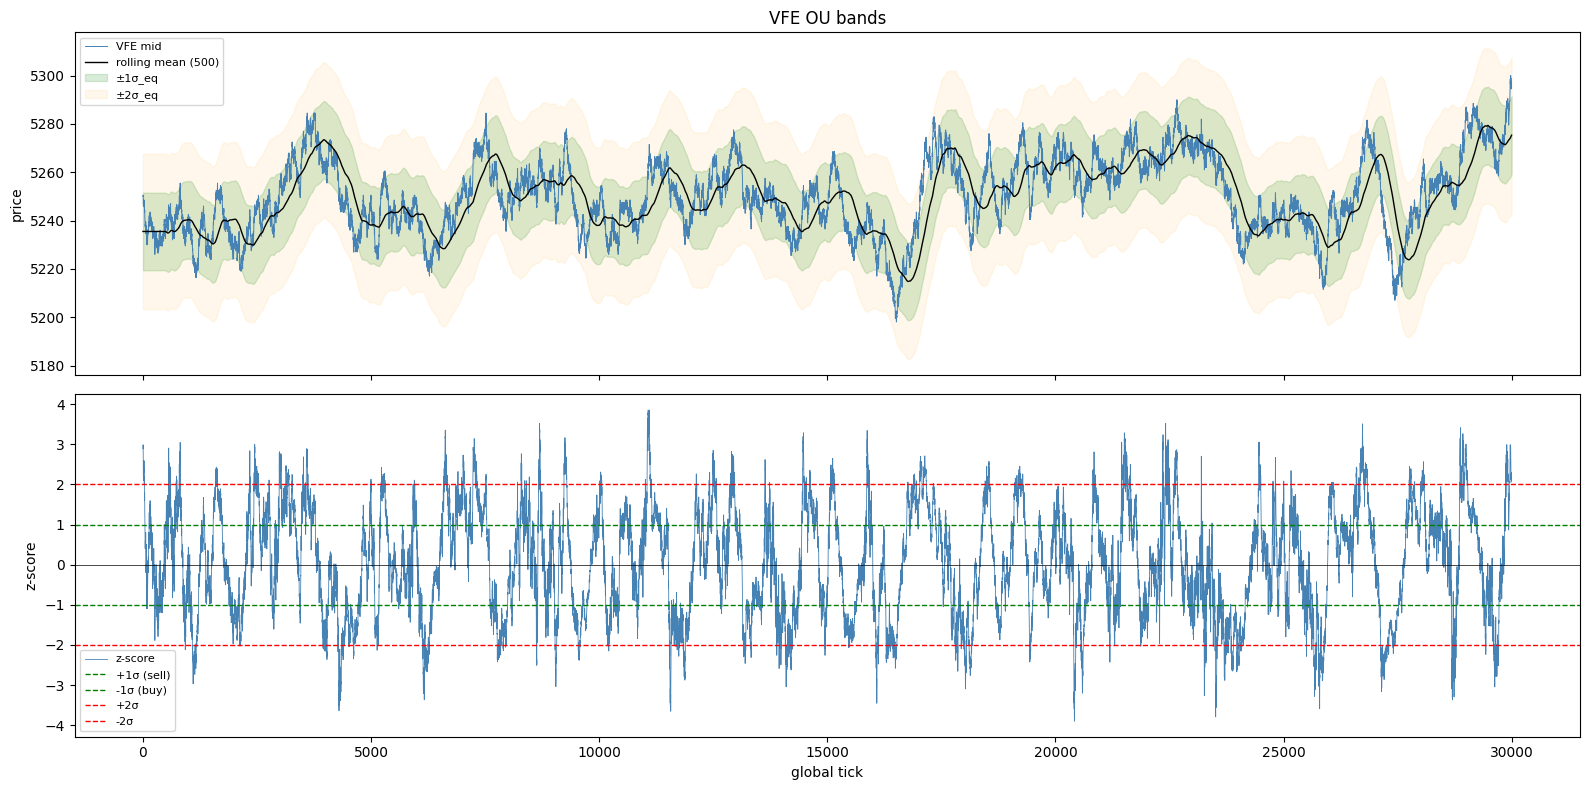

z-score outside ±1σ: 52.6% of ticks
z-score outside ±2σ: 13.4% of ticks


In [65]:
# Plot VFE price with OU bands and z-score
# Problem: mu is global — use rolling OU instead (rolling mean as mu proxy)
window = 500
p_series = vfe['mid_price']
rolling_mu = p_series.rolling(window).mean().bfill()
rolling_std = p_series.rolling(window).std().bfill()
z = (p_series - rolling_mu) / rolling_std

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

ax1.plot(vfe['global_tick'], p_series,     lw=0.7, color='steelblue', label='VFE mid')
ax1.plot(vfe['global_tick'], rolling_mu,   lw=1.0, color='black',     label=f'rolling mean ({window})')
ax1.fill_between(vfe['global_tick'],
                 rolling_mu - sigma_eq, rolling_mu + sigma_eq,
                 alpha=0.15, color='green', label='±1σ_eq')
ax1.fill_between(vfe['global_tick'],
                 rolling_mu - 2*sigma_eq, rolling_mu + 2*sigma_eq,
                 alpha=0.08, color='orange', label='±2σ_eq')
ax1.legend(fontsize=8)
ax1.set_ylabel('price')
ax1.set_title('VFE OU bands')

ax2.plot(vfe['global_tick'], z, lw=0.6, color='steelblue', label='z-score')
ax2.axhline(1,  color='green',  lw=1, ls='--', label='+1σ (sell)')
ax2.axhline(-1, color='green',  lw=1, ls='--', label='-1σ (buy)')
ax2.axhline(2,  color='red',    lw=1, ls='--', label='+2σ')
ax2.axhline(-2, color='red',    lw=1, ls='--', label='-2σ')
ax2.axhline(0,  color='black',  lw=0.5)
ax2.legend(fontsize=8)
ax2.set_ylabel('z-score')
ax2.set_xlabel('global tick')

plt.tight_layout()
plt.show()

print(f"z-score outside ±1σ: {(z.abs() > 1).mean()*100:.1f}% of ticks")
print(f"z-score outside ±2σ: {(z.abs() > 2).mean()*100:.1f}% of ticks")


In [67]:
# Analyse order flow imbalance for VFE
# OFI = (total_bid_size - total_ask_size) / total_size
vfe_ob = prices[prices['product'] == 'VELVETFRUIT_EXTRACT'].copy()
vfe_ob['global_tick'] = vfe_ob['day'] * TICKS_PER_DAY + (vfe_ob['timestamp'] // 100).astype(int)
vfe_ob = vfe_ob.sort_values('global_tick').reset_index(drop=True)

# sum all bid/ask levels available
bid_cols = [c for c in vfe_ob.columns if c.startswith('bid_volume')]
ask_cols = [c for c in vfe_ob.columns if c.startswith('ask_volume')]
print("Bid cols:", bid_cols)
print("Ask cols:", ask_cols)
print(vfe_ob.columns.tolist())


Bid cols: ['bid_volume_1', 'bid_volume_2', 'bid_volume_3']
Ask cols: ['ask_volume_1', 'ask_volume_2', 'ask_volume_3']
['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1', 'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3', 'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2', 'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss', 'global_tick']


In [68]:
# Compute OFI and test predictive power
vfe_ob['total_bid'] = vfe_ob[['bid_volume_1','bid_volume_2','bid_volume_3']].sum(axis=1)
vfe_ob['total_ask'] = vfe_ob[['ask_volume_1','ask_volume_2','ask_volume_3']].sum(axis=1)
vfe_ob['total'] = vfe_ob['total_bid'] + vfe_ob['total_ask']
vfe_ob['ofi'] = (vfe_ob['total_bid'] - vfe_ob['total_ask']) / vfe_ob['total']

# next-tick return
vfe_ob['next_ret'] = vfe_ob['mid_price'].shift(-1) - vfe_ob['mid_price']

# correlation of OFI with next return
corr = vfe_ob[['ofi','next_ret']].dropna().corr()
print("OFI vs next-tick return correlation:")
print(corr)
print()

# bin OFI into quintiles, show mean next return per bin
vfe_ob['ofi_bin'] = pd.qcut(vfe_ob['ofi'], 5, labels=['very_neg','neg','neutral','pos','very_pos'])
print("Mean next-tick return by OFI quintile:")
print(vfe_ob.groupby('ofi_bin', observed=True)['next_ret'].mean())
print()

# also check best-bid/ask volume ratio (level 1 only)
vfe_ob['l1_ofi'] = (vfe_ob['bid_volume_1'] - vfe_ob['ask_volume_1']) / (vfe_ob['bid_volume_1'] + vfe_ob['ask_volume_1'])
corr_l1 = vfe_ob[['l1_ofi','next_ret']].dropna().corr()
print("Level-1 OFI vs next-tick return correlation:")
print(corr_l1)


OFI vs next-tick return correlation:
               ofi  next_ret
ofi       1.000000 -0.320833
next_ret -0.320833  1.000000



ValueError: Bin edges must be unique: Index([-0.18181818181818182, 0.0, 0.0, 0.0, 0.0, 0.2222222222222222], dtype='float64', name='ofi').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [38]:
from scipy.stats import norm
from scipy.optimize import minimize_scalar
import math
import warnings
warnings.filterwarnings('ignore')

def bs_call(S, K, sigma, T):
    """Black-Scholes call, r=0."""
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * norm.cdf(d2)

def merton_call(S, K, sigma, T, lam, mu_j, sigma_j, n_terms=20):
    """
    Merton (1976) jump-diffusion call price, r=0.
    lam     : jump arrival rate (jumps per tick)
    mu_j    : mean log jump size
    sigma_j : std of log jump size
    """
    if T <= 0:
        return max(S - K, 0.0)

    kappa  = np.exp(mu_j + 0.5 * sigma_j**2) - 1
    lam_p  = lam * (1 + kappa)

    price = 0.0
    for n in range(n_terms):
        w       = np.exp(-lam_p * T) * (lam_p * T)**n / math.factorial(n)
        sigma_n = np.sqrt(sigma**2 + n * sigma_j**2 / T) if T > 0 else sigma
        S_n     = S * np.exp(-kappa * lam * T + n * (mu_j + 0.5 * sigma_j**2))
        price  += w * bs_call(S_n, K, sigma_n, T)
    return price

# Fit jump params from VFE return distribution (3-sigma threshold)
log_rets    = vfe['log_ret'].dropna()
sig_base    = log_rets.std()
jumps       = log_rets[log_rets.abs() > 3 * sig_base]
non_jumps   = log_rets[log_rets.abs() <= 3 * sig_base]

lam_fit     = len(jumps) / len(log_rets)
mu_j_fit    = jumps.mean()  if len(jumps)   else 0.0
sigma_j_fit = jumps.std()   if len(jumps) > 1 else sig_base
sigma_fit   = non_jumps.std()

print(f'sigma (diffusion) = {sigma_fit:.6f}')
print(f'lambda (jump/tick) = {lam_fit:.6f}  ({lam_fit*10000:.1f} jumps/day)')
print(f'mu_j   = {mu_j_fit:.6f}')
print(f'sigma_j = {sigma_j_fit:.6f}')

print(f'\nSanity — Merton vs binomial:')
S_ex = vfe['mid_price'].mean()
for K in STRIKES:
    m = merton_call(S_ex, K, sigma_fit, TOTAL_TICKS, lam_fit, mu_j_fit, sigma_j_fit)
    b = binomial_european(S_ex, K, sigma_fit, TOTAL_TICKS)
    print(f'  VEV_{K}: merton={m:.2f}  binomial={b:.2f}  diff={m-b:.2f}')

sigma (diffusion) = 0.000208
lambda (jump/tick) = 0.006800  (68.0 jumps/day)
mu_j   = -0.000073
sigma_j = 0.000707

Sanity — Merton vs binomial:
  VEV_4500: merton=0.00  binomial=750.12  diff=-750.12
  VEV_5000: merton=0.00  binomial=268.27  diff=-268.27
  VEV_5100: merton=0.00  binomial=189.23  diff=-189.23
  VEV_5200: merton=0.00  binomial=124.36  diff=-124.36
  VEV_5300: merton=0.00  binomial=75.28  diff=-75.28


In [39]:
# Price all strikes with Merton at every tick and compare to market
merton_results = []
for strike in STRIKES:
    prod = f'VEV_{strike}'
    opt = prices[prices['product'] == prod][['day','timestamp','mid_price']].copy()
    opt['global_tick'] = opt['day'] * TICKS_PER_DAY + (opt['timestamp'] // 100).astype(int)
    opt = opt.sort_values('global_tick').reset_index(drop=True)
    opt = opt.merge(
        vfe[['global_tick','mid_price','sigma']].rename(columns={'mid_price':'S'}),
        on='global_tick', how='left')
    opt['sigma']   = opt['sigma'].ffill().bfill()
    opt['T_ticks'] = TOTAL_TICKS - opt['global_tick']
    opt['merton']  = opt.apply(lambda r: merton_call(
        r['S'], strike, r['sigma'], max(r['T_ticks'], 1),
        lam_fit, mu_j_fit, sigma_j_fit), axis=1)
    opt['mkt']     = opt['mid_price']
    opt['misp_merton'] = opt['mkt'] - opt['merton']
    opt['strike']  = strike
    merton_results.append(opt)
    print(f'VEV_{strike}: merton={opt["merton"].mean():.1f}  market={opt["mkt"].mean():.1f}  '
          f'bias={opt["misp_merton"].mean():.1f}  std={opt["misp_merton"].std():.1f}')

all_merton = pd.concat(merton_results, ignore_index=True)

VEV_4500: merton=0.0  market=750.1  bias=750.1  std=15.6


KeyboardInterrupt: 

In [ ]:
# Merton vs binomial vs market
fig, axes = plt.subplots(len(STRIKES), 1, figsize=(14, 3*len(STRIKES)))
for ax, strike in zip(axes, STRIKES):
    dm = all_merton[all_merton['strike'] == strike]
    db = all_opts[all_opts['strike'] == strike]
    ax.plot(dm['global_tick'], dm['mkt'],    lw=0.8, color='steelblue', label='market')
    ax.plot(db['global_tick'], db['model'],  lw=0.8, color='tomato',    ls='--', label='binomial')
    ax.plot(dm['global_tick'], dm['merton'], lw=0.8, color='green',     ls=':', label='merton')
    ax.set_title(f'VEV_{strike}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Mispricing: merton vs binomial side by side
fig, axes = plt.subplots(2, len(STRIKES), figsize=(14, 6))
for i, strike in enumerate(STRIKES):
    db = all_opts[all_opts['strike'] == strike]['misp'].dropna()
    dm = all_merton[all_merton['strike'] == strike]['misp_merton'].dropna()
    axes[0, i].hist(db, bins=50, color='tomato', alpha=0.7)
    axes[0, i].axvline(0, color='k', lw=1)
    axes[0, i].set_title(f'VEV_{strike}\nBinomial bias={db.mean():.1f}')
    axes[1, i].hist(dm, bins=50, color='green', alpha=0.7)
    axes[1, i].axvline(0, color='k', lw=1)
    axes[1, i].set_title(f'Merton bias={dm.mean():.1f}')
axes[0, 0].set_ylabel('market − binomial')
axes[1, 0].set_ylabel('market − merton')
plt.tight_layout()
plt.show()